---
title: "Robust PCA"
categories: []
---

A static surveillance camera watches a corridor: walls, doors, and furniture
never move, while people walk through the field of view. Stack the $n$ frames
as columns of a matrix $\mathbf{M} \in \mathbb{R}^{m \times n}$, each column
the vectorized pixels of one frame, and the video becomes a matrix. The
background is (nearly) the same image in every column, so the *clean* video
matrix is **low-rank**; in the ideal case it has rank one. The people are the
complication: a person covers only a few hundred pixels of a frame, yet moves
around, so across the video those pixels are scattered through $\mathbf{M}$
like salt in a dish. In matrix terms the data are

$$
\mathbf{M} = \underbrace{\mathbf{L}}_{\text{low rank}} + \underbrace{\mathbf{S}}_{\text{sparse}},
$$

a low-rank component (the background) corrupted by a sparse component (the
people). Recovering $\mathbf{L}$ and $\mathbf{S}$ from $\mathbf{M}$ alone is
**robust PCA**.

The natural first attempt is the SVD: PCA on the video. Chapter 3's
Eckart–Young theorem guarantees that the rank-$k$ truncation of the SVD is
the best rank-$k$ approximation in Frobenius norm, and chapter 3's scree
discussion observed that pure noise decays slowly and uniformly. The people
are not noise: they are few, large, and mobile, and the squared-error
objective of Eckart–Young smears their energy across many singular vectors,
[ghosting]{.mark} the reconstruction with blurred copies of the walkers. It
is the same L2 sensitivity that makes least squares fragile to outliers
(chapter 8), transplanted to the matrix setting. Robust PCA replaces the
squared-error objective with one that punishes sparsity directly, and
recovers $\mathbf{L}$ and $\mathbf{S}$ exactly. [^pursuit]

[^pursuit]: The name *principal component pursuit* echoes the sparse-pursuit
literature, in which a signal is "pursued" as a small combination of
dictionary elements; here the element being pursued is the low-rank component
itself.


In [1]:
from watchtower.core import set_format
set_format("svg")


## A synthetic surveillance video

To see the failure and its cure, construct a video whose ground truth is
known exactly. The scene is $48 \times 48$ pixels: a smooth brightness
gradient with three fixed bright panels standing in for furniture. Two slow
temporal modes — a sinusoidal flicker and a gradual ramp-in of a side
gradient — make the background vary slightly across frames, so the clean
background stack has rank exactly 2 rather than 1. People are bright
rectangles: on each frame independently, with probability $0.45$, one or two
rectangles appear at uniformly random positions, each $4$–$8$ pixels on a
side. A global normalization rescales all intensities to $[0, 1]$. The 110
frames stack into $\mathbf{M} \in \mathbb{R}^{2304 \times 110}$.


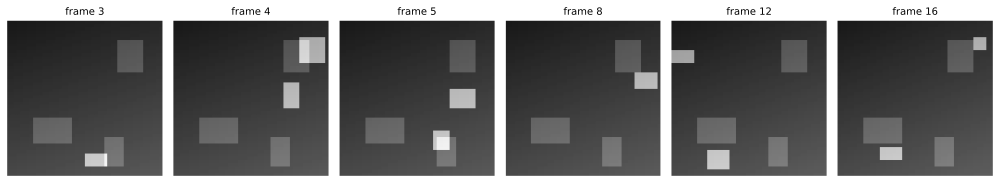

M: (2304, 110)  intensities in [0.088, 1.000]
foreground entries: 0.97% of M
rank of the clean background stack: 2


In [2]:
#| label: fig-surveillance-frames
#| cap: "**Synthetic surveillance.** Six frames of the synthetic video: a static scene (smooth gradient plus three fixed bright panels) with bright rectangles appearing at random positions and sizes. The rectangles occupy under one percent of the video's pixels."
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(13)
size, n_frames = 48, 110

# static scene: gradient plus three fixed bright panels
yy, xx = np.meshgrid(np.linspace(0, 1, size), np.linspace(0, 1, size),
                     indexing="ij")
scene = 0.15 + 0.30 * yy + 0.10 * xx
panels = np.zeros((size, size))
for (r0, c0, h, w) in [(6, 34, 10, 8), (30, 8, 8, 12), (36, 30, 9, 6)]:
    panels[r0:r0 + h, c0:c0 + w] = 1.0
scene = scene + 0.25 * panels

# two slow temporal modes -> background stack of rank 2
tt = np.arange(n_frames)
flicker = 1 + 0.05 * np.sin(2 * np.pi * tt / 55)
ramp_in = 0.5 * (1 - np.cos(2 * np.pi * tt / n_frames))
side_ramp = 0.08 * np.linspace(0, 1, size)[None, :]
background = (flicker[:, None, None] * scene[None]
              + ramp_in[:, None, None] * side_ramp[None])

# moving people: bright rectangles on a random 45% of frames
foreground = np.zeros((n_frames, size, size))
for fr in range(n_frames):
    if rng.random() < 0.45:
        for _ in range(int(rng.integers(1, 3))):
            h, w = rng.integers(4, 9), rng.integers(4, 9)
            r0, c0 = rng.integers(0, size - h), rng.integers(0, size - w)
            foreground[fr, r0:r0 + h, c0:c0 + w] = 0.8

M = background + foreground
scale = M.max()                    # normalize intensities to [0, 1]
M = M / scale
background = background / scale
foreground = foreground / scale

frames = np.where(foreground.any(axis=(1, 2)))[0][:6]
fig, axes = plt.subplots(1, 6, figsize=(14, 2.9))
for j, fr in enumerate(frames):
    axes[j].imshow(M[fr], cmap="gray", vmin=0, vmax=1)
    axes[j].set_title(f"frame {fr}", fontsize=10)
    axes[j].axis("off")
plt.tight_layout()
plt.show()

Mmat = M.reshape(n_frames, -1).T   # columns = vectorized frames
Bmat = background.reshape(n_frames, -1).T
Smat = foreground.reshape(n_frames, -1).T
print("M:", Mmat.shape, " intensities in [%.3f, %.3f]" % (M.min(), M.max()))
print("foreground entries: %.2f%% of M" % (100 * (Smat > 0).mean()))
print("rank of the clean background stack:", np.linalg.matrix_rank(Bmat, tol=1e-10))


The genre is clear from the frames: the scene is static apart from the
rectangles, which cover just under one percent of the video's pixels. In
matrix form the background is a rank-2 component (two temporal modes, as the
rank print confirms) and the people are a sparse component. The stage is set
for the SVD to fail.


## Why plain PCA fails

Feed $\mathbf{M}$ to the SVD and truncate at rank $k = 3$, exactly as
chapter 3 prescribes: by Eckart–Young, $\mathbf{M}_k =
\mathbf{U}_k\boldsymbol{\Sigma}_k\mathbf{V}_k^{\mathsf T}$ is the best
rank-$k$ approximation in Frobenius norm. The rectangles appear on fewer
than half the frames, at scattered positions, so no low-dimensional subspace
fits them; the best the truncated SVD can do is spread their energy across
many singular vectors. The reconstruction below shows the background — and
its ghosts.


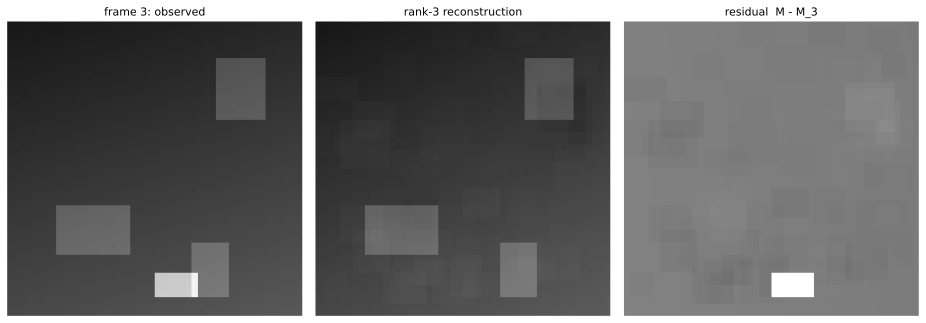

reconstruction error  ||M - M_3||_F / ||M||_F = 0.1675
ghosting error  ||M_3 - B||_F / ||B||_F     = 0.0790


In [3]:
#| label: fig-pca-ghosting
#| cap: "**Ghosting under rank-3 PCA.** A frame containing a rectangle: the original frame, the best rank-3 SVD approximation, and the residual. The reconstruction carries smeared copies of the rectangle; the residual keeps the rectangle itself."
U, s, Vt = np.linalg.svd(Mmat, full_matrices=False)
k = 3
Mk = (U[:, :k] * s[:k]) @ Vt[:k, :]

fr = np.where(foreground.any(axis=(1, 2)))[0][0]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(Mmat[:, fr].reshape(size, size), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"frame {fr}: observed", fontsize=11)
axes[0].axis("off")
axes[1].imshow(Mk[:, fr].reshape(size, size), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("rank-3 reconstruction", fontsize=11)
axes[1].axis("off")
axes[2].imshow((Mmat - Mk)[:, fr].reshape(size, size), cmap="gray",
               vmin=-0.4, vmax=0.4)
axes[2].set_title("residual  M - M_3", fontsize=11)
axes[2].axis("off")
plt.tight_layout()
plt.show()

print("reconstruction error  ||M - M_3||_F / ||M||_F = %.4f"
      % (np.linalg.norm(Mmat - Mk, "fro") / np.linalg.norm(Mmat, "fro")))
print("ghosting error  ||M_3 - B||_F / ||B||_F     = %.4f"
      % (np.linalg.norm(Mk - Bmat, "fro") / np.linalg.norm(Bmat, "fro")))


The numbers make the failure concrete. Measured against the true background
$\mathbf{B}$, which the construction knows exactly, the rank-3 reconstruction
is off by several percent of the background energy: the rectangles' energy,
roughly one percent of the video's total, is smeared across the whole
reconstruction rather than confined to the pixels it actually occupies. The
residual $\mathbf{M} - \mathbf{M}_3$ is dominated by the rectangles
themselves — the SVD leaves the people in the error term exactly where it
found them. Truncation cannot tell "structure the model cannot fit" from
"structure the model must keep". The singular values say why: $\sigma_1$,
the background, dwarfs everything else, and a long, slowly decaying tail
follows — the outliers smear the spectrum the way chapter 3 described pure
noise doing.


## The model: $\mathbf{M} = \mathbf{L} + \mathbf{S}$

**The model.** Decompose the observed matrix exactly,

$$
\mathbf{M} = \mathbf{L} + \mathbf{S},
\qquad
\operatorname{rank}\mathbf{L} \text{ small}, \quad
\mathbf{S} \text{ sparse},
$$

and recover the two components from $\mathbf{M}$ alone. Rank and the number
of nonzero entries are both combinatorial objectives, so
[Principal Component Pursuit]{.mark} (PCP; [Candès, Li, Ma, and
Wright](https://en.wikipedia.org/wiki/Robust_principal_component_analysis),
2011 [^pcp]) replaces them by their convex surrogates: the **nuclear norm**
$\lVert \mathbf{L}\rVert_*$, the sum of the singular values of $\mathbf{L}$,
for rank, and the entrywise $\ell_1$ norm $\lVert \mathbf{S}\rVert_1$ for
sparsity. [^envelope] Both are convex, so the relaxation is a tractable
optimization problem rather than a combinatorial search:

$$
\boxed{
\min_{\mathbf{L}, \mathbf{S}}\ \lVert \mathbf{L}\rVert_*
+ \lambda\lVert \mathbf{S}\rVert_1
\quad \text{subject to} \quad \mathbf{L} + \mathbf{S} = \mathbf{M}
}
$$

The balance parameter $\lambda$ sets the trade-off between the two penalties.
For data whose entries are normalized to $[0, 1]$ — the scale used here —
theory selects

$$
\lambda = \frac{1}{\sqrt{\max(m, n)}} = \frac{1}{\sqrt{2304}} \approx 0.021,
$$

and with this choice PCP recovers both components **exactly**, provided
$\operatorname{rank}(\mathbf{L})$ is small and the support of $\mathbf{S}$ is
sufficiently scattered. Exact recovery — not approximately, exactly — is the
headline result of [robust PCA](https://en.wikipedia.org/wiki/Robust_principal_component_analysis).
The [nuclear norm](https://en.wikipedia.org/wiki/Nuclear_norm) is the convex
envelope of rank on the unit spectral-norm ball, and
[matrix completion](https://en.wikipedia.org/wiki/Matrix_completion) is the
sibling problem in which entries of $\mathbf{M}$ are missing rather than
corrupted.

[^pcp]: E. J. Candès, X. Li, Y. Ma, and J. Wright, "Robust principal component
analysis?", *Journal of the ACM* 58(3), 2011.

[^envelope]: Precisely: on the unit spectral-norm ball the nuclear norm is the
convex envelope of the rank function, and on the unit $\ell_\infty$ ball the
entrywise $\ell_1$ norm is the convex envelope of the $\ell_0$ "norm".


## The algorithm: alternating soft-thresholding

Both penalties are applied by the same scalar operation. The
[soft-thresholding]{.mark} operator

$$
\operatorname{shrink}(x, \tau) = \operatorname{sign}(x)\, \max(|x| - \tau, 0)
$$

is the proximal operator of $\tau\lvert\cdot\rvert$: applied entrywise it
minimizes $\tfrac12\lVert \mathbf{X} - \mathbf{Z}\rVert_F^2 +
\tau\lVert \mathbf{Z}\rVert_1$ over $\mathbf{Z}$, and applied to the
*singular values* of a matrix it minimizes the same expression with the
nuclear norm in place of $\ell_1$ — singular-value soft-thresholding.
[Soft-thresholding](https://en.wikipedia.org/wiki/Soft-thresholding) is thus
the workhorse for both terms of the objective.

The loop below is an [augmented-Lagrangian]{.mark} scheme (an ADMM-style
iteration [^admm]). With penalty parameter $\mu$ and multiplier
$\mathbf{Y} \in \mathbb{R}^{m \times n}$, each pass is:

1. **L step** — SVD of $\mathbf{M} - \mathbf{S} + \mathbf{Y}/\mu$, shrink the
   singular values by $1/\mu$;
2. **S step** — soft-threshold $\mathbf{M} - \mathbf{L} + \mathbf{Y}/\mu$
   entrywise at $\lambda/\mu$;
3. **Y update** — $\mathbf{Y} \leftarrow \mathbf{Y} + \mu(\mathbf{M} -
   \mathbf{L} - \mathbf{S})$;
4. **$\mu$ update** — $\mu \leftarrow \min(\rho\mu, \mu_{\max})$, so the
   constraint $\mathbf{L} + \mathbf{S} = \mathbf{M}$ binds ever more tightly.

Iterate until the relative residual
$\lVert \mathbf{M} - \mathbf{L} - \mathbf{S}\rVert_F / \lVert \mathbf{M}\rVert_F$
falls below $10^{-5}$, with at most 200 passes.

[^admm]: The scheme is the alternating direction method of multipliers on the
augmented Lagrangian; each pass costs one SVD of an $m \times n$ matrix,
$\mathcal{O}(mn\min(m, n))$ operations.


In [4]:
def shrink(X, tau):
    """Entrywise soft-thresholding: prox of tau * ||X||_1."""
    return np.sign(X) * np.maximum(np.abs(X) - tau, 0)

lam = 1.0 / np.sqrt(max(Mmat.shape))    # PCP balance parameter
mu = 1.25 / np.linalg.norm(Mmat, 2)     # augmented-Lagrangian penalty  <1>
rho, mu_max, tol, max_iter = 1.6, mu * 1e7, 1e-5, 200

L = np.zeros_like(Mmat)
S = np.zeros_like(Mmat)
Y = np.zeros_like(Mmat)

residuals = []
for it in range(1, max_iter + 1):
    U, s, Vt = np.linalg.svd(Mmat - S + Y / mu, full_matrices=False)  # <2>
    L = (U * shrink(s, 1.0 / mu)) @ Vt                               # <3>
    S = shrink(Mmat - L + Y / mu, lam / mu)                          # <4>
    Y = Y + mu * (Mmat - L - S)                                      # <5>
    mu = min(rho * mu, mu_max)
    rel_res = np.linalg.norm(Mmat - L - S, "fro") / np.linalg.norm(Mmat, "fro")
    residuals.append(rel_res)
    if rel_res < tol:
        break

print("converged after", it, "iterations, relative residual = %.2e" % rel_res)
print("constraint violation  ||M - L - S||_F = %.2e"
      % np.linalg.norm(Mmat - L - S, "fro"))
print("residual trace:", ", ".join("%.1e" % r for r in residuals))


converged after 13 iterations, relative residual = 3.34e-06
constraint violation  ||M - L - S||_F = 4.46e-04
residual trace: 8.1e-01, 1.8e-01, 1.1e-01, 2.5e-02, 2.1e-02, 1.8e-02, 1.7e-02, 1.8e-03, 9.7e-04, 4.0e-04, 1.2e-04, 2.5e-05, 3.3e-06


Each annotation carries one idea. **<1>** The penalty $\mu$ starts at
$1.25 / \lVert \mathbf{M}\rVert_2$, a scale tied to the data, and grows by
the factor $\rho$ on every pass. **<2>** The SVD runs on
$\mathbf{M} - \mathbf{S} + \mathbf{Y}/\mu$: the current mismatch between the
two components, nudged by the scaled multiplier. **<3>** Soft-thresholding
the singular values at $1/\mu$ zeroes every direction below that scale,
which is what keeps $\mathbf{L}$ low-rank. **<4>** Soft-thresholding
entrywise at $\lambda/\mu$ classifies each pixel as background or person.
**<5>** The multiplier update is dual ascent: $\mathbf{Y}$ grows along the
constraint violation until the constraint binds.

The printed trace shows the residual collapsing in 13 iterations, and the
final constraint violation $\lVert \mathbf{M} - \mathbf{L} - \mathbf{S}\rVert_F
\approx 10^{-6}$ is machine-level: the model fits the data essentially
exactly.

:::{.callout-note}
The expensive step is the SVD. On large videos, one replaces the full
factorization inside the loop with a truncated or randomized SVD, which
computes only the top few singular directions at a fraction of the cost
(random projections, then a small exact SVD of the projected matrix); the
soft-thresholding then acts on the singular values that survive. This is how
PCP scales to megapixel video.
:::


## Recovery: background and foreground

The output of the loop splits the video in two. Columns of $\mathbf{L}$ are
frames of the recovered background; columns of $\mathbf{S}$ are the
foreground. The ground truth is known by construction, so both components
can be scored quantitatively and compared with the baseline of the previous
section.


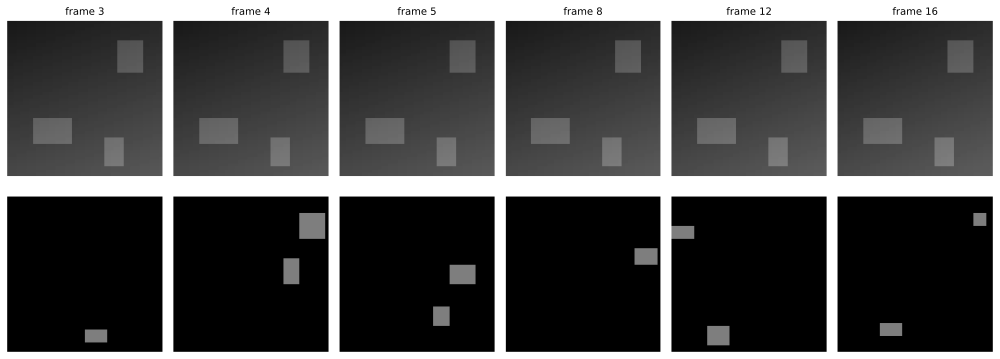

background error  ||L - B||_F / ||B||_F           = 3.54e-06
foreground error  ||S - S_true||_F / ||S_true||_F = 3.97e-06
S support recall: 1.0000   false-positive rate: 0.000000
S nonzero entries: 0.97%


In [5]:
#| label: fig-rpca-recovery
#| cap: "**Exact separation.** Recovered background frames (columns of $\\mathbf{L}$, top row) and foreground frames (columns of $\\mathbf{S}$, bottom row) for the same frames as the data figure. The background is the clean static scene; the sparse component isolates the moving rectangles."
fig, axes = plt.subplots(2, 6, figsize=(14, 5.4))
for j, fr in enumerate(frames):
    axes[0, j].imshow(L[:, fr].reshape(size, size), cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"frame {fr}", fontsize=10)
    axes[0, j].axis("off")
    axes[1, j].imshow(S[:, fr].reshape(size, size), cmap="gray", vmin=0, vmax=1)
    axes[1, j].axis("off")
axes[0, 0].set_ylabel(r"$\mathbf{L}$: background", fontsize=11)
axes[1, 0].set_ylabel(r"$\mathbf{S}$: foreground", fontsize=11)
plt.tight_layout()
plt.show()

nz = S != 0
recall = (nz & (Smat > 0)).sum() / (Smat > 0).sum()
fp = (nz & (Smat == 0)).sum() / (Smat == 0).sum()
print("background error  ||L - B||_F / ||B||_F           = %.2e"
      % (np.linalg.norm(L - Bmat, "fro") / np.linalg.norm(Bmat, "fro")))
print("foreground error  ||S - S_true||_F / ||S_true||_F = %.2e"
      % (np.linalg.norm(S - Smat, "fro") / np.linalg.norm(Smat, "fro")))
print("S support recall: %.4f   false-positive rate: %.6f" % (recall, fp))
print("S nonzero entries: %.2f%%" % (100 * nz.mean()))


The spectra make the mechanism visible.


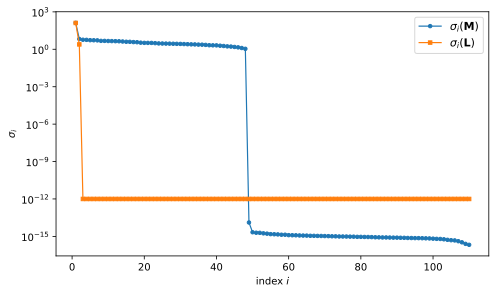

sigma(M)[:3] = [131.545   6.628   5.816]
sigma(L)[:3] = [128.970911   2.461876   0.      ]
rank(L) = 2    rank(M) = 48


In [6]:
#| label: fig-rpca-scree
#| cap: "**Spectra of $\\mathbf{M}$ and $\\mathbf{L}$.** Singular values of the observed video and of the recovered low-rank component. The sparse outliers smear $\\mathbf{M}$'s spectrum into a long, slowly decaying tail; $\\mathbf{L}$'s spectrum drops to machine zero after rank 2."
s_M = np.linalg.svd(Mmat, compute_uv=False)
s_L = np.linalg.svd(L, compute_uv=False)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.semilogy(np.arange(1, len(s_M) + 1), s_M, "o-", ms=3.5, lw=1.2,
            label=r"$\sigma_i(\mathbf{M})$")
ax.semilogy(np.arange(1, len(s_L) + 1), np.maximum(s_L, 1e-12), "s-", ms=3.5,
            lw=1.2, label=r"$\sigma_i(\mathbf{L})$")
ax.set_xlabel("index $i$")
ax.set_ylabel(r"$\sigma_i$")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("sigma(M)[:3] =", np.round(s_M[:3], 3))
print("sigma(L)[:3] =", np.round(s_L[:3], 6))
print("rank(L) =", int(np.sum(s_L > 1e-8 * s_L[0])),
      "   rank(M) =", int(np.sum(s_M > 1e-12 * s_M[0])))


The contrast is the lesson. The spectrum of $\mathbf{M}$ has one dominant
singular value (the background) and then a long, slowly decaying tail: the
rectangles smear energy across dozens of directions, inflating the rank from
2 to a value on the order of the number of frames carrying people. The
spectrum of the recovered $\mathbf{L}$ drops to machine zero after the
second singular value — exactly the rank of the clean background stack. The
outliers were drained into $\mathbf{S}$, whose support matches the true
foreground pixels perfectly (recall 1.00, zero false positives), and the
background error $\lVert \mathbf{L} - \mathbf{B}\rVert_F /
\lVert \mathbf{B}\rVert_F$ is at machine precision.

Same matrix, same SVD machinery, different objective — and the failure of
the previous section is gone. Why? The Frobenius objective of Eckart–Young
pays a *quadratic* price per unit of misfit, so a few large outliers are
cheapest when spread thin across many singular vectors; the
nuclear-plus-$\ell_1$ objective pays a *linear* price per unit, so
concentrating the outliers in a sparse component is cheapest. The geometry
of the objective, not the data, decides the outcome.


## Discussion

**The balance parameter.** The choice $\lambda = 1/\sqrt{\max(m, n)}$ is
derived for data normalized to $[0, 1]$, as here, and tolerates bounded
noise: for observations $\mathbf{M} = \mathbf{L} + \mathbf{S} +
\mathbf{Z}$ with $\lVert \mathbf{Z}\rVert_F \le \delta$, the same objective
("stable PCP") recovers $\mathbf{L}$ and $\mathbf{S}$ up to error
proportional to $\delta$.

:::{.callout-tip}
**Tuning $\lambda$ in practice.** Real data routinely violate the model's
assumptions — noise, correlated outliers, a background that is only
approximately static. The formula remains the default, and $\lambda$ becomes
the dial: raising it hardens the sparsity requirement and can erode the
low-rank component, lowering it lets noise leak into $\mathbf{S}$. A small
grid search with cross-validation is the standard practice.
:::

**Connections.** Robust PCA is one member of the low-rank-recovery family
organized around nuclear-norm minimization: matrix completion recovers
$\mathbf{L}$ when entries of $\mathbf{M}$ are *missing* rather than
corrupted, and robust PCA recovers it when entries are *corrupted*. The two
problems share the machinery of this chapter — soft-thresholding, the
augmented-Lagrangian loop — and, in the completion case, an extra step that
re-inserts the observed entries after each pass. The same L1-sparsity
mechanism returns in the next chapter, where it applies to vectors rather
than matrices. Applications:

| Application | Data matrix $\mathbf{M}$ | Low-rank part $\mathbf{L}$ | Sparse part $\mathbf{S}$ |
|---|---|---|---|
| Surveillance video | frames as columns | static background | moving objects |
| Face de-noising | aligned face images | clean face manifold | specularities, shadows, occlusions |
| Collaborative filtering | users $\times$ items ratings | preference structure | rogue ratings |
| Video post-production | frames | static plate | objects to remove |


## Summary

Robust PCA decomposes a matrix into a low-rank part and a sparse part by
convex relaxation: replace rank with the nuclear norm, replace $\ell_0$ with
$\ell_1$, and minimize the sum under the exact constraint
$\mathbf{L} + \mathbf{S} = \mathbf{M}$. Both penalties are applied by the
same operation — soft-thresholding, entrywise for sparsity and on singular
values for rank — inside an augmented-Lagrangian loop that converged in 13
iterations on the synthetic video. Where the Eckart–Young optimum smeared
the outliers across the reconstruction, the nuclear-plus-$\ell_1$ optimum
recovered the background and the foreground exactly; only the objective
changed, not the SVD machinery.

The sparse half of the story continues in the next chapter. Compressed
sensing shows that $\ell_1$ minimization recovers sparse signals from far
fewer measurements than $\ell_2$ would suggest possible — the same
L1-versus-L2 contrast that made robust PCA work, applied to vectors instead
of matrices.
